#### 머신러닝

In [22]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [5]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()

# 이름은 통계에 영향이 거의 없거나 완전히 없음
# male, female은 범주형 데이터.
# 나이에 소수점이 있는 이유는 NaN값이 하나라도 있으면 int에서 전부 float형태로 바뀜
# 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic.info()
# 숫자만 있는 줄 알았는데 문자열(str)이 껴있을 수도 있으므로 info로 꼭 확인하기

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
titanic['Age'].describe()
# 누락값이 제외된 결과임

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age'>

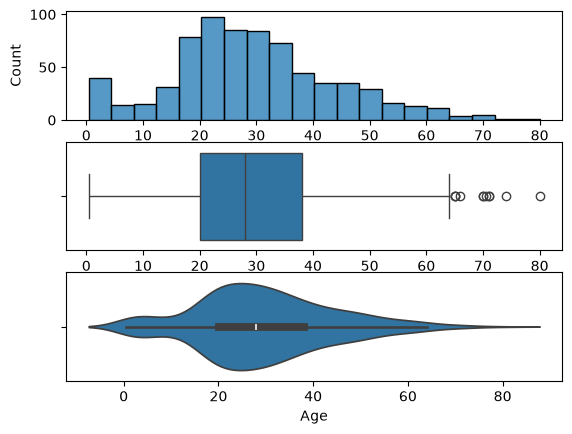

In [8]:
plt.subplot(3,1,1)
sns.histplot(data = titanic, x = 'Age')
plt.subplot(3,1,2)
sns.boxplot(data = titanic, x = 'Age')
plt.subplot(3,1,3)
sns.violinplot(data = titanic, x = 'Age')

In [ ]:
titanic['Fare'].describe()
# 표준편차가 매우 큰 것을 확인 할 수 있음
# 보통은 평균 - 표준편차 했을 때 음수가 나오지 않지만 이번 데이터는 음수가 나옴
# 즉 한쪽으로 많이 쏠려있을 가능성이 매우 높다.
# 최소값은 $0이고 최고값이 $512인걸로 보아 차이가 매우 큰 것을 확인 할 수 있음
# 중앙값이 14인걸 보아 요금이 적은 쪽으로 치우쳐있을 가능성이 매우 높다.
# 돈을 안내고 탄 승객의 경우를 생각해보면
# 갓난아기는 돈을 받지 않았을 가능성
# 배의 승무원일 가능성

# 3/4인 사람들은 평균가격인 $32보다 싸게 금액을 지불한 것을 확인할 수 있음($31)

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare'>

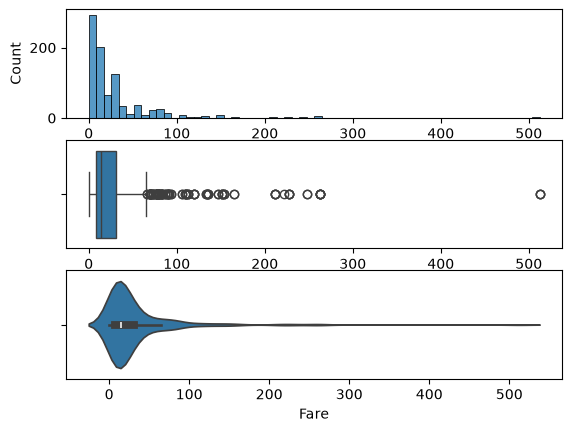

In [10]:
plt.subplot(3,1,1)
sns.histplot(data = titanic, x = 'Fare')
plt.subplot(3,1,2)
sns.boxplot(data = titanic, x = 'Fare')
plt.subplot(3,1,3)
sns.violinplot(data = titanic, x = 'Fare') 

In [ ]:
# 이상치 판단
# IQR
IQR = titanic['Fare'].quantile(0.75) - titanic['Fare'].quantile(0.25)
high_border = titanic['Fare'].quantile(0.75) + IQR * 1.5
    # quantile(0.75)는 q3를 구하라는 의미. 즉 75%

low_border = titanic['Fare'].quantile(0.25) - IQR * 1.5
print(high_border, low_border) 

65.6344 -26.724


<Axes: xlabel='Fare'>

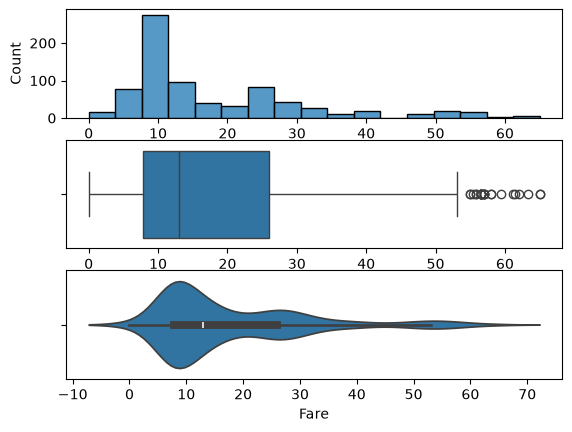

In [12]:
titanic2 = titanic[(titanic['Fare'] < high_border) & (titanic['Fare'] > low_border)]
plt.subplot(3,1,1)
sns.histplot(data = titanic2, x = 'Fare')
plt.subplot(3,1,2)
sns.boxplot(data = titanic2, x = 'Fare')
plt.subplot(3,1,3)
sns.violinplot(data = titanic2, x = 'Fare')

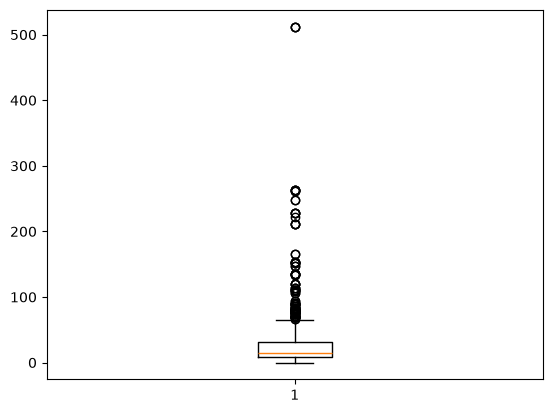

In [15]:
box = plt.boxplot(titanic['Fare'])

In [16]:
box

{'whiskers': [<matplotlib.lines.Line2D at 0x1c04d7c52b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c04d7c5550>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c04d7c5160>],
 'medians': [<matplotlib.lines.Line2D at 0x1c04d7c57f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c04d7c5940>],
 'means': []}

In [ ]:
print(box['whiskers'][0].get_xdata())
print(box['whiskers'][1].get_ydata())   # 31은 상자의 윗부분, 65는 수염의 끝부분

[1 1]
[31. 65.]


In [21]:
titanic[titanic['Fare'] < 65.6344]['Fare'].max()

np.float64(65.0)

In [ ]:
# 이상치 판단
# zscore : 평균에서 떨어진 정도로 이상치 검출, 2~3의 값으로 검출
z_score = np.abs(titanic['Fare'] - titanic['Fare'].mean()) / titanic['Fare'].std()
titanic3 = titanic[z_score < 2.5]

<Axes: xlabel='Fare'>

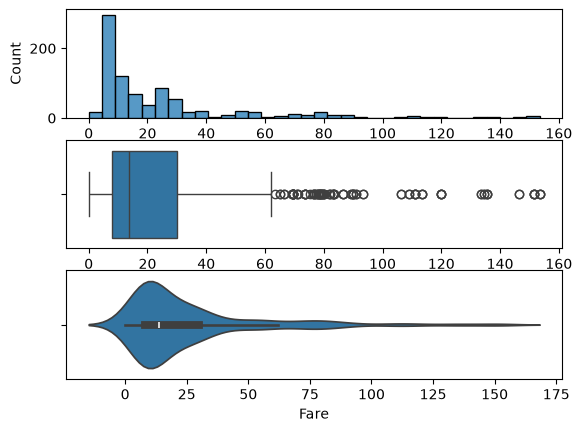

In [23]:
plt.subplot(3,1,1)
sns.histplot(data = titanic3, x = 'Fare')
plt.subplot(3,1,2)
sns.boxplot(data = titanic3, x = 'Fare')
plt.subplot(3,1,3)
sns.violinplot(data = titanic3, x = 'Fare')

In [25]:
titanic['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [27]:
titanic['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
titanic['Survived'].value_counts() / titanic.shape[0]

# 비율이 맞는지 확인하는게 좋다

Survived
0    0.616162
1    0.383838
Name: count, dtype: float64

In [ ]:
titanic['Sex'].describe()

# 숫자값이 아니고 범주형이라서 이렇게 나옴

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

In [ ]:
titanic['Pclass'].unique()

array([3, 1, 2])

In [24]:
print(titanic['Pclass'].value_counts())
print(titanic['Pclass'].value_counts() / len(titanic['Pclass']))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    0.551066
1    0.242424
2    0.206510
Name: count, dtype: float64


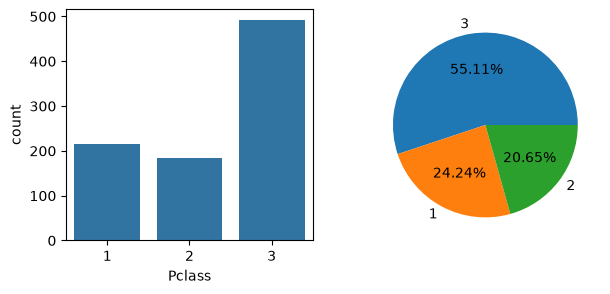

In [31]:
p_cnt = titanic['Pclass'].value_counts()
plt.figure(figsize = (7, 3))
plt.subplot(1,2,1)
sns.countplot(data = titanic, x = 'Pclass')
plt.subplot(1,2,2)
plt.pie(p_cnt.values, labels = p_cnt.index, autopct = '%.2f%%') 

In [32]:
air = pd.read_csv('data/ozone.csv')
air.head() 

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


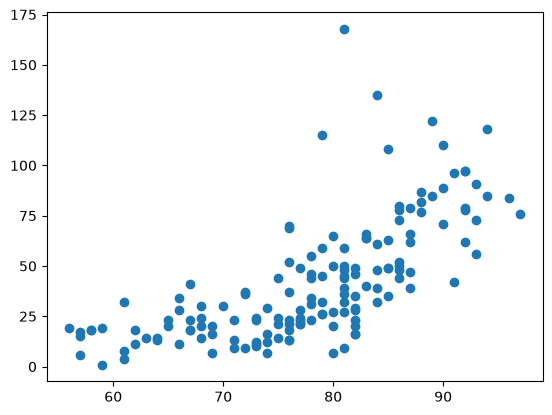

In [33]:
plt.scatter('Temp', 'Ozone', data=air)

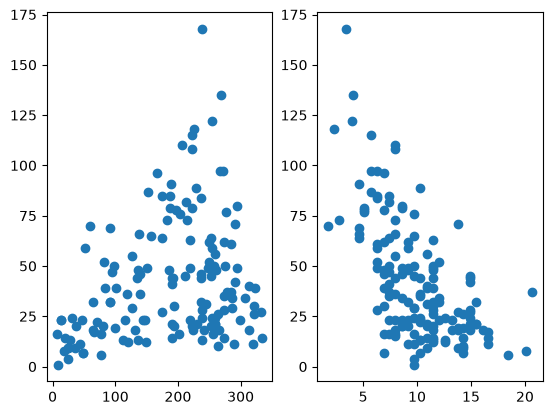

In [34]:
plt.subplot(1,2,1)
plt.scatter('Solar.R', 'Ozone', data=air)
plt.subplot(1,2,2)
plt.scatter('Wind', 'Ozone', data=air)

<Axes: xlabel='Temp', ylabel='Ozone'>

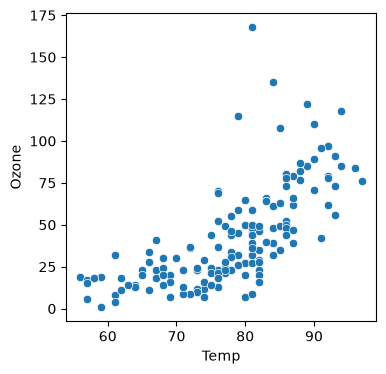

In [ ]:
plt.figure(figsize = (4, 4))
sns.scatterplot(x = 'Temp', y = 'Ozone', data = air)

# 산점도는 독립변수와 종속변수가 수치형일 때 두 변수의 관계성을 바로 파악하기 위해 사용한다.